# Étape 1 - Collecte, appariement et préparation des données

**Corpus :** Professions de foi des législatives 1993 (corpus Archelec / CEVIPOF)  
**Objectif :** Construire un DataFrame complet textes+métadonnées, nettoyer les textes, et produire une analyse descriptive initiale.

# 0.Imports

In [31]:
import re
import json
import random
from pathlib import Path
from io import TextIOWrapper
from zipfile import ZipFile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import spacy

random.seed(42)
np.random.seed(42)

# Paths (adjust if needed)
DATA_DIR = Path("../data")
ZIP_1993 = DATA_DIR / "legislatives_1993.zip"
META_CSV = DATA_DIR / "meta_archelect_1993.csv"

print("ZIP exists:", ZIP_1993.exists())
print("Meta CSV exists:", META_CSV.exists())

ZIP exists: True
Meta CSV exists: True


# 1. Chargement des textes

Les fichiers `.txt` du zip sont issus d'une OCR. On conserve l'identifiant de chaque document (nom du fichier sans extension) pour l'appariement ultérieur avec les métadionnées. 

**Remarque :** Certains fichiers du zip se terminent par `_BV_pdfmasterocr`. Ce sont des *biulletins de vote*, hors périmètre. Nous conservons donc juste les 5842 fichiers de professions de foi appariables au csv.

In [32]:
records = {}

with ZipFile(ZIP_1993) as zf:
    for name in zf.namelist():
        if not name.endswith(".txt"):
            continue
        doc_id = Path(name).stem
        # Exclure les bulletins de vote
        if doc_id.endswith("_BV_pdfmasterocr"):
            continue
        with zf.open(name) as f:
            try:
                txt = TextIOWrapper(f, encoding="utf-8", errors="replace").read()
            except Exception:
                f.seek(0)
                txt = TextIOWrapper(f, encoding="latin-1", errors="replace").read()
            records[doc_id] = txt

print(f"{len(records)} professions de foi chargées")

5842 professions de foi chargées


# 2. Appariement avec les métadonnées

Le csv `meta_archelect_1993.csv` contient les métadonnées Archelec : parti (soutien), âge, etc. L'identifiant commun est le champ `id`. 

In [33]:
df_meta = pd.read_csv(META_CSV)
df_texts = pd.DataFrame({"id": list(records.keys()), "raw_text": list(records.values())})

df = df_meta.merge(df_texts, on="id", how="inner")

df.head(10)

,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,raw_text
0,EL189_L_1993_03_001_01_1_PF_01,1993-03-21,France;Ve République;Assemblée Nationale;Élect...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 50 et 59 ans,gendarme,non mentionné,non mentionné,professionnel,retraité,Front national,non mentionné,non,ELECTIONS LEGISLATIVES DE MARS 93\nFRONT NATIO...
1,EL189_L_1993_03_001_01_1_PF_02,1993-03-21,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,agent territorial,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
2,EL189_L_1993_03_001_01_1_PF_03,1993-03-21,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,non mentionné,maire;conseiller général,non mentionné,non mentionné,non mentionné,Union pour la démocratie française;Rassembleme...,non mentionné,oui,Sciences Po / fonds CEVIPOF\nElections législa...
3,EL189_L_1993_03_001_01_1_PF_04,1993-03-21,Élections législatives;Assemblée Nationale;Fra...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 40 et 49 ans,enseignant lycée d'enseignement professionnel,non mentionné,non mentionné,non mentionné,non mentionné,Lutte ouvrière,non mentionné,non,Elections législatives du 21 mars 1993\nPourqu...
4,EL189_L_1993_03_001_01_1_PF_05,1993-03-21,Ve République;Élections législatives;France;As...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 20 et 29 ans,non mentionné,non mentionné,non mentionné,non mentionné,étudiant,Verts;Génération écologie,Entente des écologistes,non,Sciences Po / fonds CEVIPOF\nRépublique França...
5,EL189_L_1993_03_001_01_1_PF_06,1993-03-21,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 30 et 39 ans,éducateur spécialisé foyer adolescents,non mentionné,non mentionné,syndicat,célibataire,Ligue communiste révolutionnaire;Alternative r...,non mentionné,non,Sciences Po / fonds CEVIPOF\nELECTIONS LEGISLA...
6,EL189_L_1993_03_001_01_1_PF_07,1993-03-21,France;Assemblée Nationale;Élections législati...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,Sciences Po / fonds CEVIPOF\nAgir ensemble\nEc...
7,EL189_L_1993_03_001_01_1_PF_08,1993-03-21,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,non mentionné,adjoint administratif,non mentionné,non mentionné,non mentionné,non mentionné,Nouveaux écologistes du rassemblement nature e...,non mentionné,non,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
8,EL189_L_1993_03_001_02_1_PF_01,1993-03-21,Ve République;Assemblée Nationale;France;Élect...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 60 et 69 ans,non mentionné,non mentionné,non mentionné,non mentionné,retraité,Front national,non mentionné,non,ELECTIONS LEGISLATIVES DE MARS 93\nFRONT NATIO...
9,EL189_L_1993_03_001_02_1_PF_02,1993-03-21,Élections législatives;Ve République;France;As...,"Élections législatives de 1993, Ain - 01, circ...",législatives,1,EL189,01,Ain,01 - Ain,...,entre 40 et 49 ans,agent de maîtrise EDF,non mentionné,non mentionné,non mentionné,non mentionné,P

In [34]:
print(f"Documents après appariement : {len(df)}")
print(f"Nombre de colonnes : {len(df.columns)}")
print(f"Colonnes disponibles : {df.columns.tolist()}")


Documents après appariement : 5837
Nombre de colonnes : 43
Colonnes disponibles : ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations', 'raw_text']


In [35]:
df["titulaire-soutien"].head(8)

0                                       Front national
1                            Parti communiste français
2    Union pour la démocratie française;Rassembleme...
3                                       Lutte ouvrière
4                            Verts;Génération écologie
5    Ligue communiste révolutionnaire;Alternative r...
6                                                libre
7    Nouveaux écologistes du rassemblement nature e...
Name: titulaire-soutien, dtype: str

# 3. 'Normalisation' de la variable de soutien

La colonne `titulaire-soutien` contient parfois plusieurs partis séparés par `;` (coalitions). 

In [36]:
COALITION_MAP = {
    # RPR-UDF (dans les deux ordres)
    frozenset(["Rassemblement pour la République", "Union pour la démocratie française"]): "RPR-UDF",
    frozenset(["Rassemblement pour la République", "Union pour la démocratie française", 
               "Centre national des indépendants"]): "RPR-UDF",
    frozenset(["Rassemblement pour la République", "Union pour la démocratie française",
               "Centre national des indépendants et paysans"]): "RPR-UDF",

    # Écologistes (Verts + GE dans tous les ordres)
    frozenset(["Verts", "Génération écologie"]): "Écologistes",
    frozenset(["Ecologie les Verts", "Génération écologie"]): "Écologistes",

    # PS + MRG
    frozenset(["Parti socialiste", "Mouvement des radicaux de gauche"]): "PS-MRG",

    # Parti des travailleurs (avec variantes internationales)
    frozenset(["Parti des travailleurs", "Alliance européenne des travailleurs"]): "Parti des travailleurs",
    frozenset(["Parti des travailleurs", "Alliance européenne des travailleurs",
               "Entente internationale des travailleurs"]): "Parti des travailleurs",
}

def normalise_soutien(soutien: str) -> str:
    if pd.isna(soutien) or soutien in ("non mentionné", "sans étiquette", "libre", 
                                        "aucun parti politique", "indépendant"):
        return "Non étiqueté"
    parties = frozenset(p.strip() for p in soutien.split(";"))
    if parties in COALITION_MAP:
        return COALITION_MAP[parties]
    if len(parties) == 1:
        return soutien.strip()
    # Coalition inconnue -> on retourne le premier
    return soutien.split(";")[0].strip()

In [37]:
df["titulaire-soutien-simplifie"] = df["titulaire-soutien"].apply(normalise_soutien)

print(df["titulaire-soutien-simplifie"].value_counts().head(20))

titulaire-soutien-simplifie
Non étiqueté                                               1115
RPR-UDF                                                     742
Front national                                              651
Parti communiste français                                   537
Nouveaux écologistes du rassemblement nature et animaux     469
Écologistes                                                 468
Parti socialiste                                            253
Lutte ouvrière                                              234
Union pour la démocratie française                          106
Rassemblement pour la République                            102
Parti de la loi naturelle                                    95
Parti des travailleurs                                       86
PS-MRG                                                       80
Ligue communiste révolutionnaire                             70
Alliance populaire                                           66
Union des in

# 4. Nettoyage des textes

Le pipeline de nettoyage prend en charge les artefacts OCR spécifiques au corpus Archelec : 
- Mentions récurrentes des archives Sciences Po / CEVIPOF
- Symboles parasites (☒, •, «»)
- Ponctuation 
- Espaces multiples

On conserve la casse pour l'instant (importance pour les embeddings ultérieurs).
Un second pipeline `clean_for_lda` procède à la mise en minuscules pour le topic modeling. 

In [38]:
# Patterns OCR spécifiques au corpus Archelec
OCR_PATTERNS = [
    (r"sciences\s+po\s*/\s*fonds\s+cevipof", " "),
    (r"sciences\s+po\s*/\s*fonds\s+cevipov", " "),
    (r"fonds\s+cevipof", " "),
    (r"fonds\s+cevipov", " "),
    (r"vu[,]?\s*le[s]?\s*candidat[s]?", " "),
    (r"imp\.\s*[^\n]*", " "),
    (r"offset[^\n]*", " "),
]

def clean_text_for_lda(text: str) -> str:
    """Nettoyage pour LDA : mise en minuscules, suppression ponctuation/chiffres.
    La casse est perdue volontairement - LDA travaille sur un bag-of-words."""
    text = text.lower()
    for pattern, repl in OCR_PATTERNS:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    text = re.sub(r"[☒☐•▪■◆●«»""„+]", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_text_for_embeddings(text: str) -> str:
    """Nettoyage pour BERTopic/SentenceTransformer : conserve la casse.
    Le modèle pré-entraîné exploite l'information portée par les majuscules."""
    for pattern, repl in OCR_PATTERNS:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    text = re.sub(r"[☒☐•▪■◆●«»""„+]", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text_lda"]        = df["raw_text"].apply(clean_text_for_lda)
df["clean_text_embeddings"] = df["raw_text"].apply(clean_text_for_embeddings)

# Longueur en mots
df["n_chars_raw"]   = df["raw_text"].str.len()
df["n_words_clean_text_lda"] = df["clean_text_lda"].str.split().str.len()
df["n_words_clean_text_embeddings"] = df["clean_text_embeddings"].str.split().str.len()

print("Aperçu du nettoyage :")
print(df[["n_chars_raw", "n_words_clean_text_lda", "n_words_clean_text_embeddings"]].describe().round(1))

Aperçu du nettoyage :
       n_chars_raw  n_words_clean_text_lda  n_words_clean_text_embeddings
count       5837.0                  5837.0                         5837.0
mean        4163.2                   656.3                          656.3
std         2065.8                   337.2                          337.2
min          168.0                    15.0                           15.0
25%         2525.0                   392.0                          392.0
50%         3898.0                   607.0                          607.0
75%         5431.0                   865.0                          865.0
max        20160.0                  3306.0                         3306.0


In [39]:
# Compter les documents trop courts
print(f"Documents < 50 mots : {(df['n_words_clean_text_lda'] < 50).sum()}")



Documents < 50 mots : 2


In [40]:
# Voir leur contenu
df[df['n_words_clean_text_lda'] < 50][['id', 'n_words_clean_text_lda', 'raw_text']]

,id,n_words_clean_text_lda,raw_text
1621,EL191_L_1993_03_040_01_1_PF_06,15,LEGISLATIVES DU. 21 MARS 1993\nCANDIDAT LIBRE ...
3029,EL194_L_1993_03_068_06_1_PF_01,36,La commission de propagande électorale a décid...


In [41]:
# Supprimer le corpus de moins <50 mots
df_clean = df[df['n_words_clean_text_lda'] >= 50].reset_index(drop=True)
print(f"Corpus final : {len(df_clean)} documents")

Corpus final : 5835 documents


# 5. Lemmatisation avec spaCy 

La lemmatisation est nécessaire pour le LDA (bag-of-words). On utilise le modèle français `fr_core_news_sm`(ou `md` si disponible).
On exclut les stopwords, la ponctuation, les tokens < 3 caractères, et on ajoute une liste de stopwords spécifiques au corpus.

In [42]:
try:
    nlp = spacy.load("fr_core_news_md")
    print("Modèle fr_core_news_md chargé")
except OSError:
    nlp = spacy.load("fr_core_news_sm")
    print("Modèle fr_core_news_sm chargé (md non disponible)")

# Stopwords supplémentaires liés au contexte électoral / artefacts OCR
EXTRA_STOPS = {
    "france", "français", "française", "francais", "francaise",
    "circonscription", "election", "elections", "legislative", "legislatives",
    "mars", "candidat", "candidats", "candidate", "candidature",
    "suppléant", "suppléante", "votez", "voter", "vote",
    "madame", "monsieur", "mademoiselle",
    "notre", "nos", "votre", "vos",
    "politique", "pays",
    "po", "fonds", "cevipof", "cevipov", "sciences",
    "cher", "chère", "chers", "chères",
    "compatriote", "compatriotes", "concitoyen", "concitoyenne",
}

for w in EXTRA_STOPS:
    nlp.vocab[w].is_stop = True

def lemmatize(text: str) -> list[str]:
    """Retourne la liste de lemmes filtrés."""
    doc = nlp(text)
    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and not token.is_stop
        and len(token) > 2
    ]


print("Lemmatisation en cours...")
df_clean["tokens"] = [
    lemmatize(text)
    for text in nlp.pipe(df_clean["clean_text_lda"], batch_size=128)
]
# Correction: la pipe spaCy prend les textes, pas les doc
df_clean["tokens"] = [lemmatize(t) for t in df_clean["clean_text_lda"]]
df_clean["n_tokens"] = df_clean["tokens"].str.len()
print(f"Lemmatisation terminée. Tokens moyens par doc : {df_clean['n_tokens'].mean():.0f}")

Modèle fr_core_news_md chargé
Lemmatisation en cours...
Lemmatisation terminée. Tokens moyens par doc : 300


# 6. Analyse descriptive

## 6.0 Nuages de mots

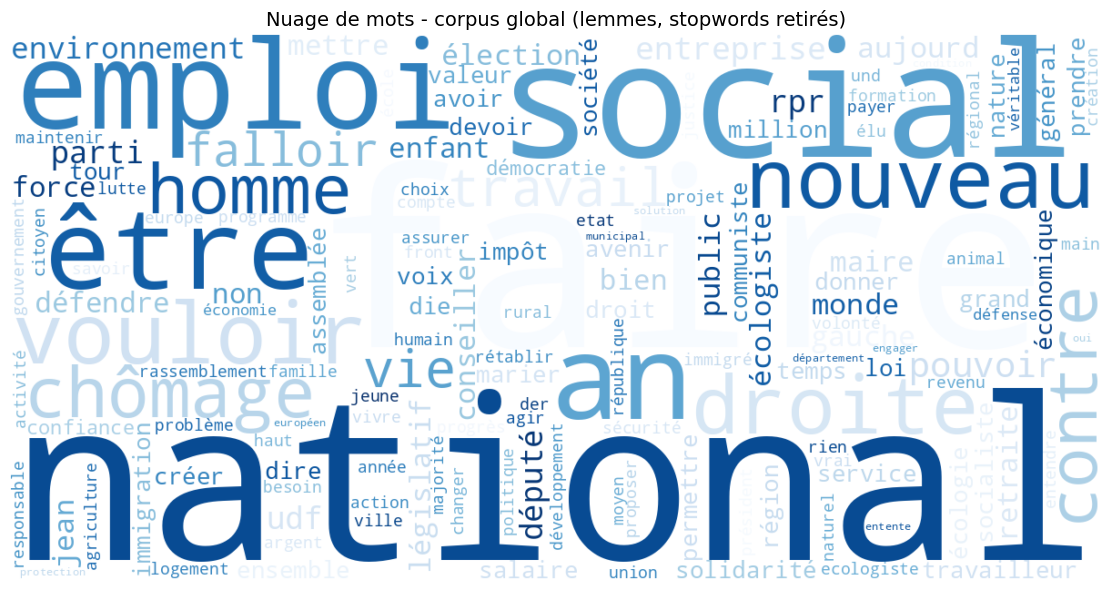

In [44]:
from wordcloud import WordCloud
from collections import Counter

# - 1. Nuage global -----------------------------
all_tokens = [t for tokens in df_clean["tokens"] for t in tokens]
freq_global = Counter(all_tokens)

wc_global = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False
).generate_from_frequencies(freq_global)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wc_global, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nuage de mots - corpus global (lemmes, stopwords retirés)", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/01_wordcloud_global.png", dpi=150, bbox_inches="tight")
plt.show()

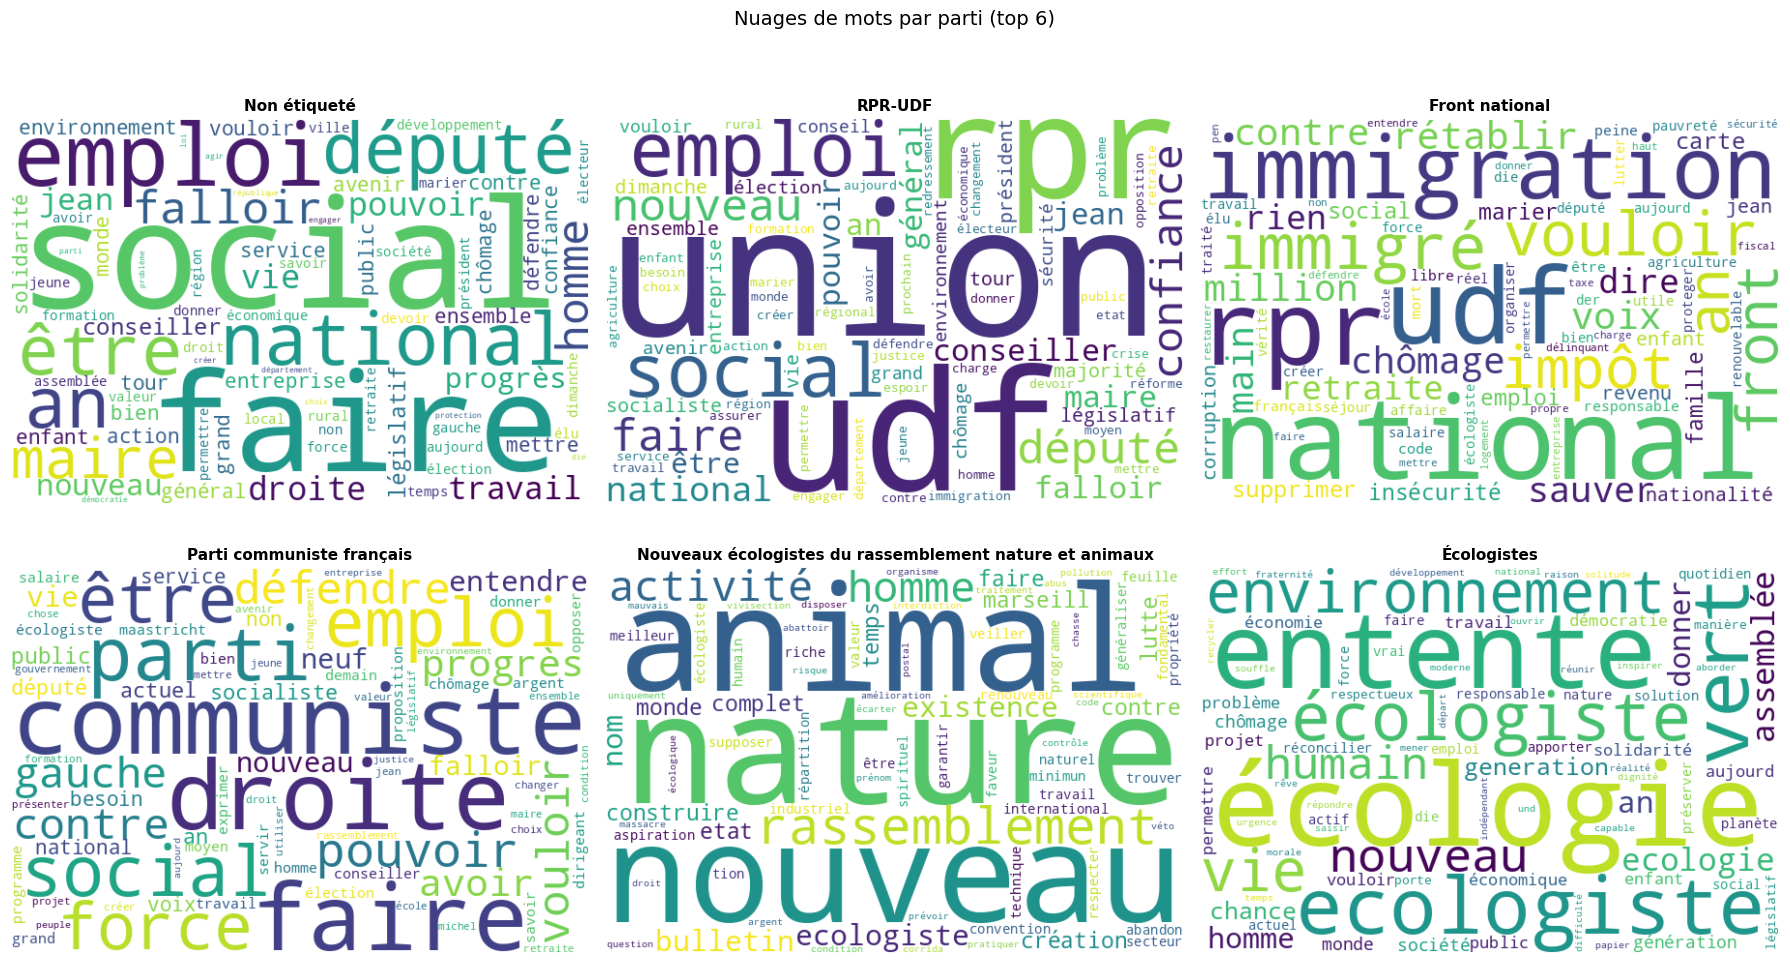

In [45]:
# - 2. Nuages par parti (pour les partis majeurs) -------------─
partis_majeurs = [p for p in df_clean["titulaire-soutien-simplifie"].value_counts().index
                  if p != "Autre / indépendant"][:6]  # top 6

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, parti in zip(axes, partis_majeurs):
    tokens_parti = [
        t
        for tokens in df_clean[df_clean["titulaire-soutien-simplifie"] == parti]["tokens"]
        for t in tokens
    ]
    freq_parti = Counter(tokens_parti)
    wc = WordCloud(
        width=600, height=400,
        background_color="white",
        colormap="viridis",
        max_words=80,
        collocations=False
    ).generate_from_frequencies(freq_parti)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(parti, fontsize=11, fontweight="bold")

plt.suptitle("Nuages de mots par parti (top 6)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../figures/01_wordcloud_partis.png", dpi=150, bbox_inches="tight")
plt.show()


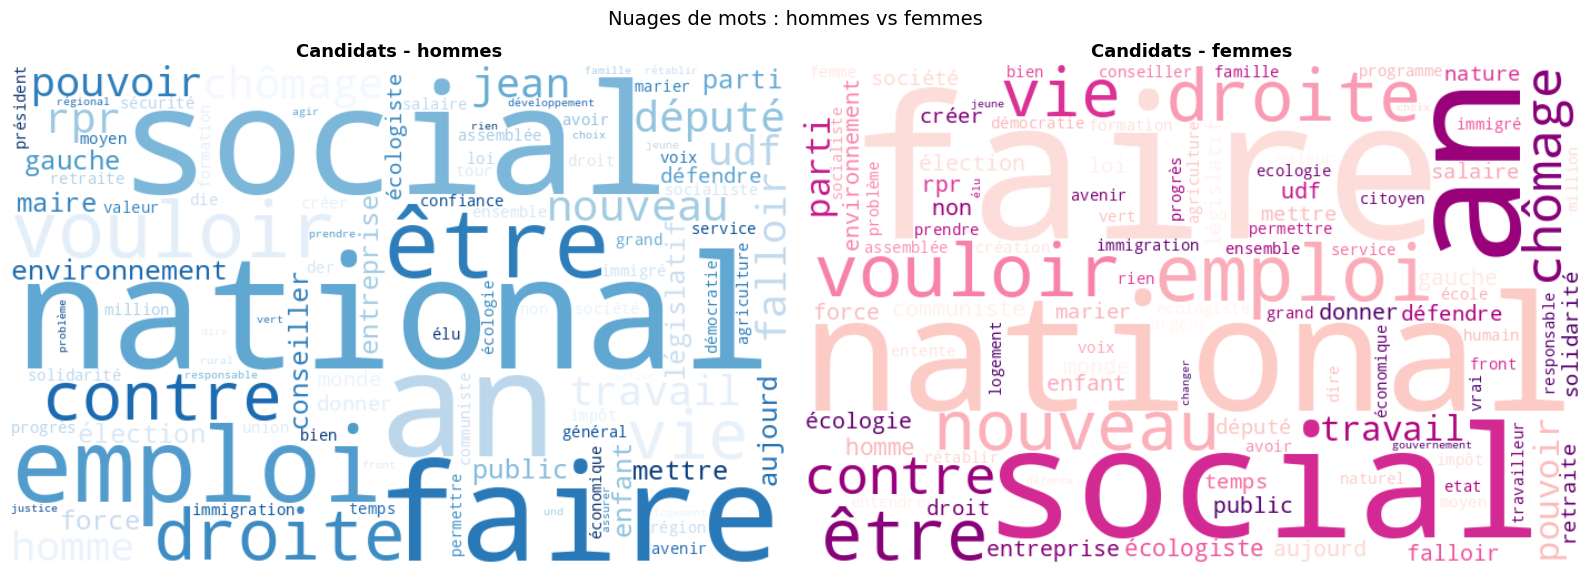

In [46]:
# - 3. Nuage hommes vs femmes ------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sexe, cmap in zip(axes, ["homme", "femme"], ["Blues", "RdPu"]):
    tokens_sexe = [
        t
        for tokens in df_clean[df_clean["titulaire-sexe"] == sexe]["tokens"]
        for t in tokens
    ]
    freq_sexe = Counter(tokens_sexe)
    wc = WordCloud(
        width=700, height=450,
        background_color="white",
        colormap=cmap,
        max_words=100,
        collocations=False
    ).generate_from_frequencies(freq_sexe)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Candidats - {sexe}s", fontsize=13, fontweight="bold")

plt.suptitle("Nuages de mots : hommes vs femmes", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/01_wordcloud_genre.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.1 Distribution par parti (soutien/coalition politique)

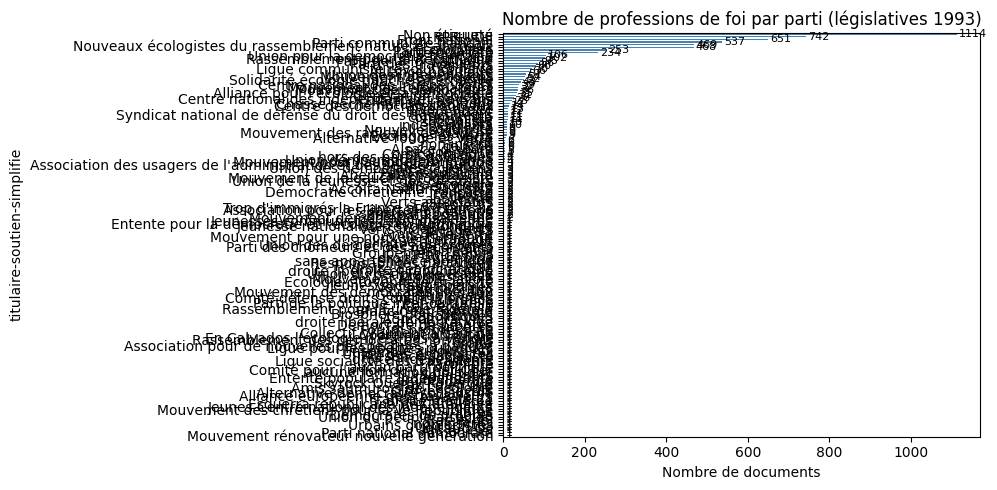

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
parti_counts = df_clean["titulaire-soutien-simplifie"].value_counts()
parti_counts.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Nombre de documents")
ax.set_title("Nombre de professions de foi par parti (législatives 1993)")
for i, v in enumerate(parti_counts.sort_values()):
    ax.text(v + 5, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/01_dist_partis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.2 Répartition par sexe

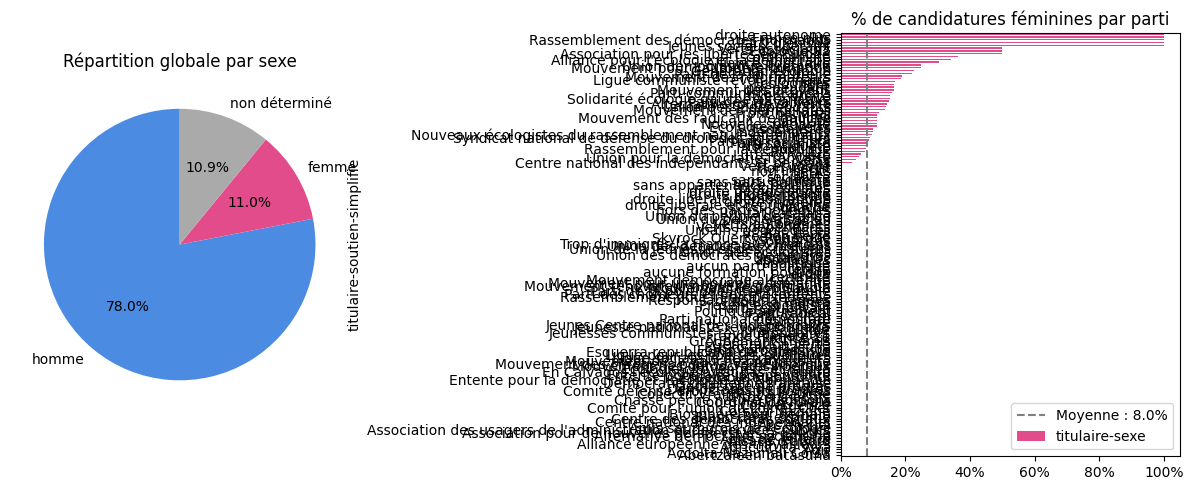

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Global
sexe_counts = df_clean["titulaire-sexe"].value_counts()
sexe_counts.plot.pie(ax=axes[0], autopct="%1.1f%%", startangle=90,
                     colors=["#4C8BE2", "#E24C8B", "#AAAAAA"])
axes[0].set_title("Répartition globale par sexe")
axes[0].set_ylabel("")

# Par parti (% femmes)
pct_femmes = (
    df_clean.groupby("titulaire-soutien-simplifie")["titulaire-sexe"]
    .apply(lambda s: (s == "femme").mean() * 100)
    .sort_values()
)
pct_femmes.plot.barh(ax=axes[1], color="#E24C8B")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("% de candidatures féminines par parti")
axes[1].axvline(x=pct_femmes.mean(), color="gray", linestyle="--", label=f"Moyenne : {pct_femmes.mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/01_dist_sexe.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.3 Distribution de la longueur des textes

TypeError: can only concatenate list (not "int") to list

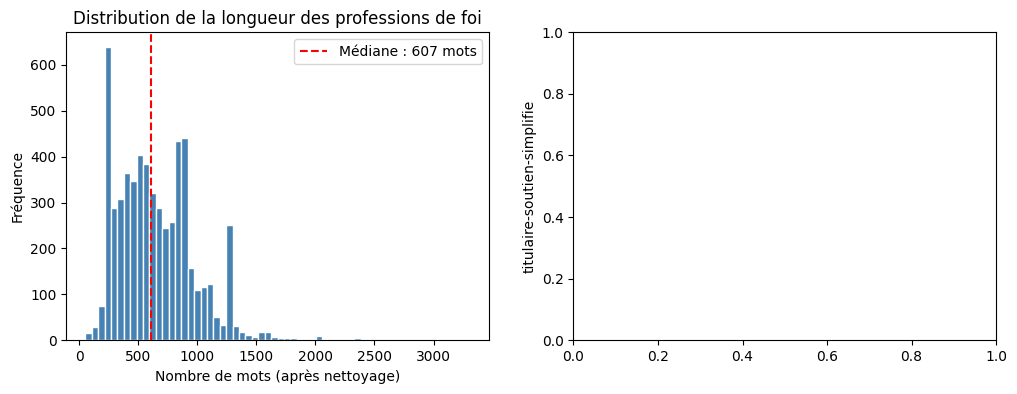

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme global
axes[0].hist(df_clean["n_words_clean_text_lda"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Nombre de mots (après nettoyage)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution de la longueur des professions de foi")
axes[0].axvline(df_clean["n_words_clean_text_lda"].median(), color="red", linestyle="--",
                label=f"Médiane : {df_clean['n_words_clean_text_lda'].median():.0f} mots")
axes[0].legend()

# Boxplot par parti
order = (df_clean.groupby("titulaire-soutien-simplifie")["n_words_clean_text_lda"]
         .median().sort_values().index.tolist())
df_clean.boxplot(column="n_words_clean_text_lda", by="titulaire-soutien-simplifie",
                 ax=axes[1], vert=False, zorder=order,
                 medianprops=dict(color="red"))
axes[1].set_title("Longueur par parti")
axes[1].set_xlabel("Nombre de mots")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../figures/01_longueur_textes.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean[["n_words_clean_text_lda", "n_tokens"]].describe().round(1))

## 6.4 Richesse lexicale (Type-Token Ratio)

Le TTR mesure la diversité du vocabulaire utilisé par chaque document. Il est sensible à la longueur du texte, donc on va le calculer sur une fenêtre fixe de 100 tokens (MSTTR).

In [53]:
WINDOW = 100

def msttr(tokens: list, window: int = WINDOW) -> float:
    """Mean Segmental TTR sur des fenêtres de longueur fixe."""
    if len(tokens) < window:
        return len(set(tokens)) / len(tokens) if tokens else 0.0
    windows = [tokens[i:i+window] for i in range(0, len(tokens) - window + 1, window)]
    return np.mean([len(set(w)) / window for w in windows])

df_clean["msttr"] = df_clean["tokens"].apply(msttr)

print("MSTTR moyen par parti:")
print(df_clean.groupby("titulaire-soutien-simplifie")["msttr"].mean().sort_values(ascending=False).round(3))

MSTTR moyen par parti:
titulaire-soutien-simplifie
Mouvement des démocrates libéraux         0.968
Parti national démocrate                  0.937
Agir                                      0.930
Entente populaire indépendante            0.930
Parti de la politique inter-culturelle    0.925
                                          ...  
Amis de la Terre                          0.765
Agricultura Viva                          0.760
Alsace d'abord                            0.754
Politique autrement                       0.740
Trop d'immigrés la France aux Français    0.736
Name: msttr, Length: 152, dtype: float64


## 6.5 Vocabulaire global et top mots fréquents

Taille du vocabulaire total (lemmes) : 50,511
Tokens totaux : 1,750,874

Top 30 lemmes les plus fréquents :
[('faire', 12636), ('national', 10931), ('social', 10717), ('emploi', 10560), ('an', 9813), ('être', 8921), ('vouloir', 8283), ('nouveau', 7882), ('droite', 7390), ('chômage', 7207), ('homme', 7042), ('contre', 6833), ('travail', 6791), ('vie', 6499), ('falloir', 6423), ('pouvoir', 6325), ('entreprise', 6091), ('rpr', 5762), ('député', 5730), ('udf', 5610), ('parti', 5609), ('environnement', 5366), ('élection', 5183), ('monde', 5100), ('législatif', 4973), ('jean', 4969), ('écologiste', 4832), ('public', 4804), ('gauche', 4725), ('aujourd', 4720)]


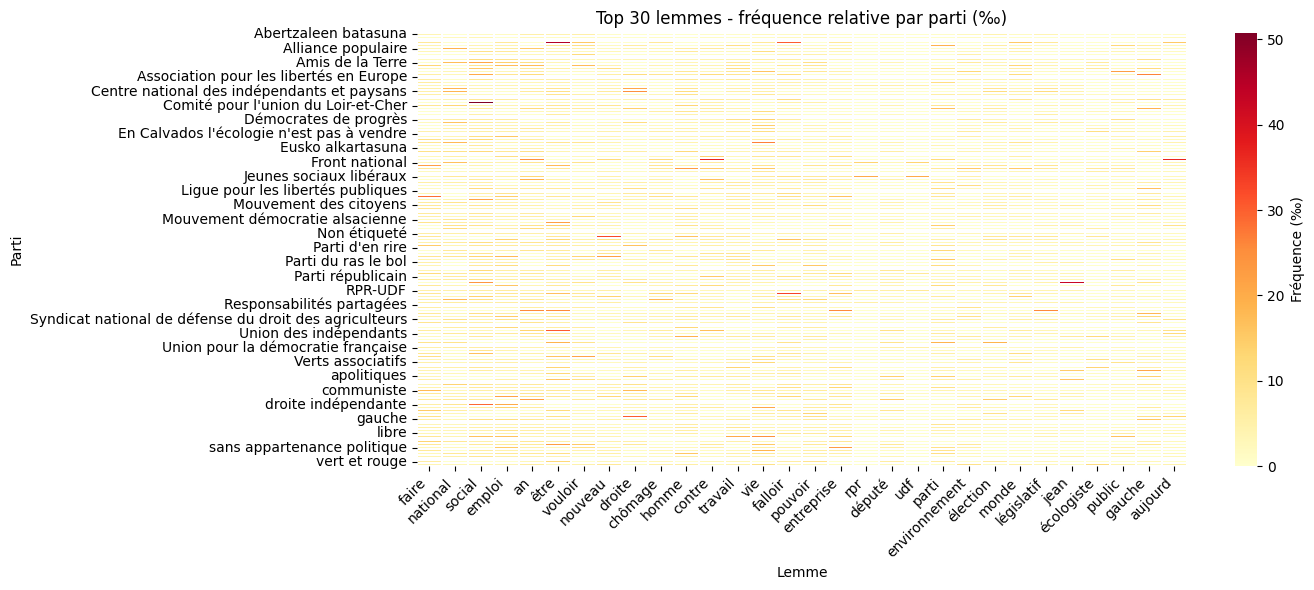

In [54]:
from collections import Counter

all_tokens = [t for tokens in df_clean["tokens"] for t in tokens]
vocab = Counter(all_tokens)

print(f"Taille du vocabulaire total (lemmes) : {len(vocab):,}")
print(f"Tokens totaux : {len(all_tokens):,}")
print(f"\nTop 30 lemmes les plus fréquents :")
print(vocab.most_common(30))

# Heatmap top mots par parti
top_words = [w for w, _ in vocab.most_common(30)]

# Fréquence relative par parti
heatmap_data = {}
for parti, grp in df_clean.groupby("titulaire-soutien-simplifie"):
    parti_tokens = [t for toks in grp["tokens"] for t in toks]
    total = len(parti_tokens)
    if total == 0:
        continue
    c = Counter(parti_tokens)
    heatmap_data[parti] = {w: c.get(w, 0) / total * 1000 for w in top_words}  # pour mille

df_heatmap = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(df_heatmap, cmap="YlOrRd", ax=ax, linewidths=0.3,
            cbar_kws={"label": "Fréquence (‰)"})
ax.set_title("Top 30 lemmes - fréquence relative par parti (‰)")
ax.set_xlabel("Lemme")
ax.set_ylabel("Parti")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/01_heatmap_vocab.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Sauvegarde du corpus préparé. 
On sauvegarde le DataFrame (sans les tokens, car trop lourd) et les tokens séparément.

In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# DataFrame principal (sans tokens pour alléger)
cols_to_save = [
    "id", "titulaire-sexe", "titulaire-profession", "titulaire-soutien",
    "parti_principal", "parti_simplifie",
    "raw_text", "clean_text",
    "n_chars_raw", "n_words_clean", "n_tokens", "msttr",
    "departement-nom", "contexte-tour"
]
df_clean[cols_to_save].to_csv("../data/processed/corpus_1993.csv", index=False)
print("Sauvegardé : data/processed/corpus_1993.csv")

# Tokens (JSON, un doc par ligne)
with open("../data/processed/tokens_1993.jsonl", "w", encoding="utf-8") as f:
    for row in df_clean[["id", "tokens"]].itertuples():
        f.write(json.dumps({"id": row.id, "tokens": row.tokens}, ensure_ascii=False) + "\n")
print("Sauvegardé : data/processed/tokens_1993.jsonl")

print(f"\n--- Résumé du corpus ---")
print(f"Documents total       : {len(df_clean)}")
print(f"Documents hommes      : {(df_clean['titulaire-sexe']=='homme').sum()}")
print(f"Documents femmes      : {(df_clean['titulaire-sexe']=='femme').sum()}")
print(f"Documents non déterm. : {(df_clean['titulaire-sexe']=='non déterminé').sum()}")
print(f"Partis représentés    : {df_clean['titulaire-soutien-simplifie'].nunique()}")
print(f"Tokens moyens/doc     : {df_clean['n_tokens'].mean():.0f}")
print(f"Taille du vocabulaire : {len(vocab):,}")